In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"F:\data analyst preparation\projects\python\telco_churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,Yes,Yes,62,Yes,No phone service,No,No,...,No internet service,No,No,No internet service,Month-to-month,No,Credit card (automatic),62.01,3845.01,Yes
1,CUST0001,Female,1,Yes,Yes,11,Yes,No phone service,No,No internet service,...,No,No internet service,No,Yes,One year,No,Bank transfer (automatic),40.49,437.84,Yes
2,CUST0002,Male,0,No,No,10,Yes,Yes,Fiber optic,Yes,...,No internet service,Yes,No,No,One year,No,Credit card (automatic),89.27,891.49,No
3,CUST0003,Male,0,Yes,Yes,12,Yes,No phone service,Fiber optic,No internet service,...,No,No,No internet service,Yes,Two year,Yes,Mailed check,90.40,1078.19,Yes
4,CUST0004,Male,0,Yes,Yes,34,Yes,No phone service,Fiber optic,No,...,Yes,No,Yes,No,Two year,Yes,Electronic check,48.27,1634.27,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,CUST7038,Female,0,No,No,25,Yes,No,DSL,No internet service,...,No,No internet service,Yes,No internet service,Two year,Yes,Electronic check,26.77,671.93,Yes
7039,CUST7039,Female,0,No,Yes,42,Yes,No phone service,No,No,...,No internet service,No,Yes,Yes,One year,No,Credit card (automatic),100.24,4213.14,No
7040,CUST7040,Female,0,No,Yes,43,Yes,Yes,No,Yes,...,Yes,No,Yes,No internet service,Two year,Yes,Mailed check,91.03,3911.29,No
7041,CUST7041,Male,1,No,Yes,37,Yes,No phone service,No,No,...,No internet service,No internet service,Yes,Yes,Month-to-month,No,Credit card (automatic),84.54,3124.00,No


### info()is used for getting the information of the columns as data type and how many non null are there

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### describe() is used for the statistics of the numerical columns

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.153486,35.664632,70.148698,2513.010849
std,0.360481,20.978092,28.578313,1896.018665
min,0.000000,0.000000,20.030000,-9.940000
25%,0.000000,17.000000,45.670000,983.230000
50%,0.000000,35.000000,70.010000,2063.980000
75%,0.000000,54.000000,94.580000,3721.825000
max,1.000000,72.000000,119.970000,8638.490000


### isnull().sum() is used to check how many missing values are there

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### duplicated().sum() is used for check how many duplicates are there

In [8]:
df.duplicated().sum()

0

### to_numeric is used to remove the blank space and fillna() is used to fill the values

In [9]:
df["TotalCharges"] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace = True)

C:\Users\tetal\AppData\Local\Temp\ipykernel_19540\3655419643.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace = True)


In [10]:
df.drop_duplicates(inplace = True)

In [11]:
df.columns = df.columns.str.lower().str.replace(" ","_")

### churn percentage

In [15]:
df["churn"].value_counts(normalize=True)*100

churn
No     73.406219
Yes    26.593781
Name: proportion, dtype: float64

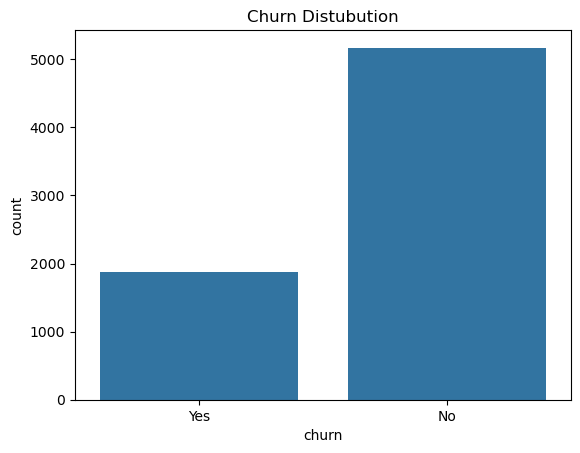

In [16]:
sns.countplot(x="churn",data=df)
plt.title("Churn Distubution")
plt.show()

### churn by gender

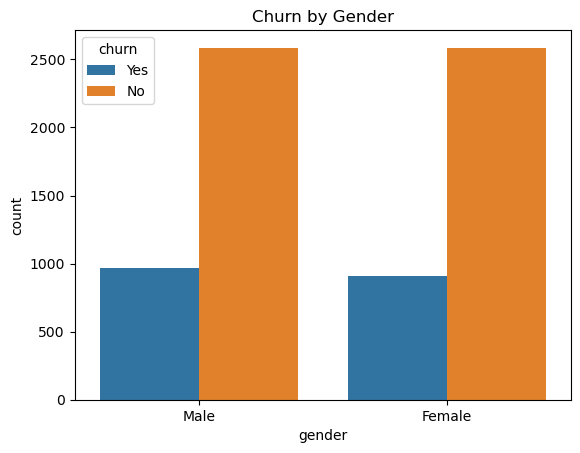

In [17]:
sns.countplot(x="gender",hue="churn",data=df)
plt.title("Churn by Gender")
plt.show()

### churn by tenure

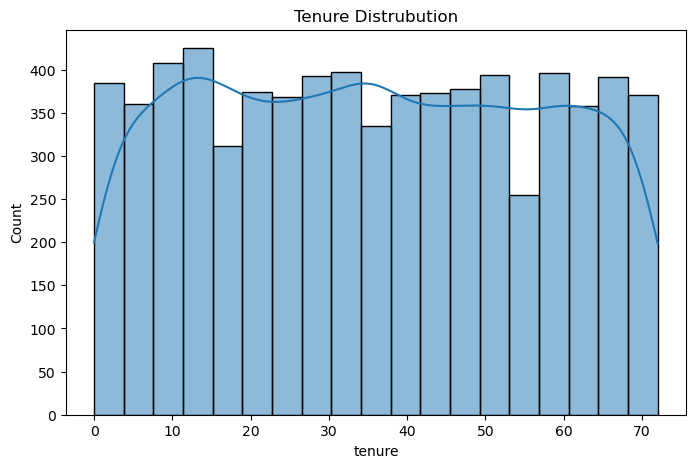

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'],kde = True)
plt.title("Tenure Distrubution")
plt.show()

### Monthly Charges vs Churn

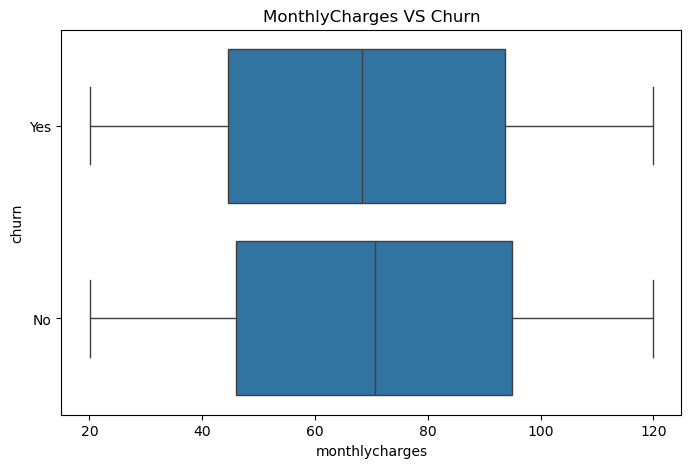

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="monthlycharges",y="churn",data=df)
plt.title("MonthlyCharges VS Churn")
plt.show()

### Churn by Contract Type

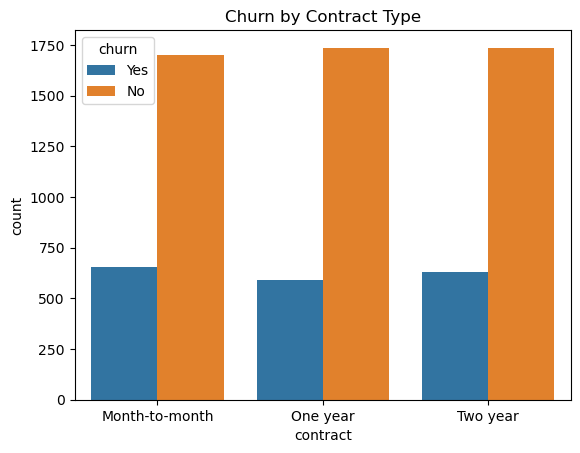

In [20]:
sns.countplot(x="contract",hue="churn",data=df)
plt.title("Churn by Contract Type")
plt.show()

### Correlation Heatmap

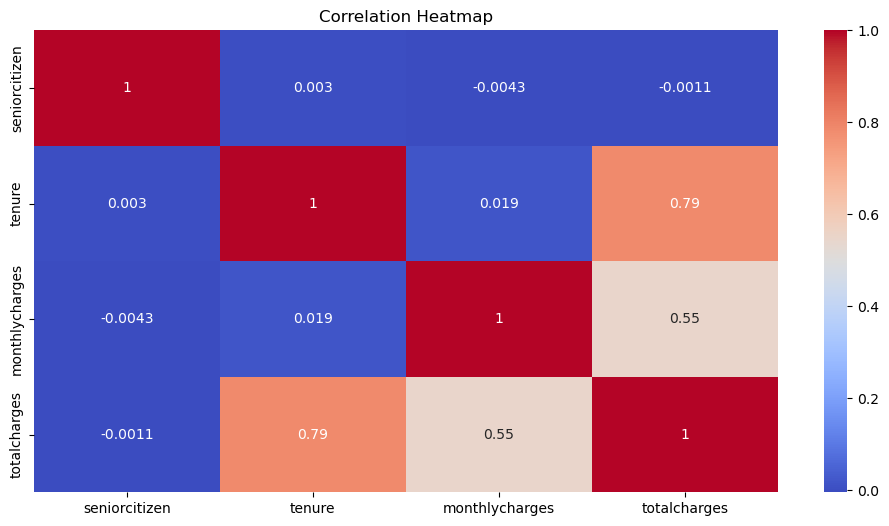

In [24]:
plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [22]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                object
dtype: object

In [23]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df

,seniorcitizen,tenure,monthlycharges,totalcharges
0,0,62,62.01,3845.01
1,1,11,40.49,437.84
2,0,10,89.27,891.49
3,0,12,90.40,1078.19
4,0,34,48.27,1634.27
...,...,...,...,...
7038,0,25,26.77,671.93
7039,0,42,100.24,4213.14
7040,0,43,91.03,3911.29
7041,1,37,84.54,3124.00
